#**I. Analyzing Reproductive Health and Behavior Patterns Using NSFG 2022–2023**

##**Objective**
* Apply statistical methods from Lectures 17–20—Poisson regression, categorical
data analysis, ordinal and nominal response modeling, and exploratory data analysis with multiple comparisons—using the NSFG 2022–2023 dataset.



**1. Dataset Acquisition**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/DSC1105_SA2/NSFG_2022_2023_FemRespPUFData.csv')

display(df.head())

,CaseID,RSCRAGE,RSCRNINF,RSCRHISP,RSCRRACE,FTFMODE,DEVICE_TYPE,AGE_R,AGESCRN,HISP,...,CMLSTYR,CMJAN3YR,CMJAN4YR,CMJAN5YR,CMFIVYR,YEAR,QUARTER,PHASE1,PHASE2,PHASE3
0,96064,29,5,5,3,2,Mobile,29,29,5,...,1474,1441,1429,1417,1426,2,4,1,0,0
1,96066,18,5,1,4,2,PC,18,18,1,...,1471,1441,1429,1417,1423,2,2,1,1,1
2,96068,37,1,5,2,2,Mobile,37,37,5,...,1473,1441,1429,1417,1425,2,4,1,0,0
3,96071,40,1,5,3,2,PC,40,40,5,...,1468,1441,1429,1417,1420,2,2,1,0,0
4,96072,49,1,5,2,2,PC,49,49,5,...,1466,1441,1429,1417,1418,2,1,1,1,0


**2. Variable Selection**

Count Variable

In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/DSC1105_SA2/NSFG_2022_2023_FemRespPUFData.csv')

print("--- COUNT VARIABLE: PREGNUM ---")

print(df['PREGNUM'].describe())
print("\nValue Counts (Number of Pregnancies):")
print(df['PREGNUM'].value_counts().sort_index())

--- COUNT VARIABLE: PREGNUM ---
count    5586.000000
mean        1.476369
std         1.806751
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        16.000000
Name: PREGNUM, dtype: float64

Value Counts (Number of Pregnancies):
PREGNUM
0     2510
1      774
2      922
3      653
4      353
5      169
6      113
7       50
8       24
9        8
10       2
11       2
12       2
13       3
16       1
Name: count, dtype: int64


* **Justification:** This variable captures the discrete number of times a respondent has been pregnant. It consists of non-negative integer values ($0, 1, 2, \dots$) and exhibits a typical right-skewed distribution where lower counts are more frequent.

* **Statistical Analysis Supported:** It will serve as the dependent ($Y$) variable for Poisson Regression Modeling (Lecture 17) to evaluate the rate of pregnancies based on different social and demographic predictors.

Categorical (Nominal) Variable

In [4]:
print("--- NOMINAL VARIABLE: RMARITAL ---")

marital_labels = {
    1: "Currently married",
    2: "Not married but cohabiting",
    3: "Widowed",
    4: "Divorced or annulled",
    5: "Separated",
    6: "Never been married"
}

print("Marital Status Frequencies:")
print(df['RMARITAL'].map(marital_labels).value_counts(dropna=False))

--- NOMINAL VARIABLE: RMARITAL ---
Marital Status Frequencies:
RMARITAL
Never been married            2498
Currently married             2060
Not married but cohabiting     627
Divorced or annulled           283
Separated                       94
Widowed                         24
Name: count, dtype: int64


* **Justification:** This variable groups respondents into distinct relational statuses ($1$ = Currently married, $2$ = Cohabiting with opposite-sex partner, $3$ = Widowed, $4$ = Divorced, $5$ = Separated, $6$ = Never married). These categories are purely qualitative and do not follow any natural mathematical progression or ranking.

* **Statistical Analysis Supported:** It will support Nominal Response Modeling via Multinomial Logistic Regression (Lecture 19) or a Chi-Square ($\chi^2$) Test of Independence (Lecture 18) to analyze how relationship status relates to other categorical health outcomes.

Ordered Categorical Variable

In [5]:
import numpy as np

print("--- ORDINAL VARIABLE: GENHEALT ---")

df['GENHEALT_CLEAN'] = df['GENHEALT'].replace([8, 9], np.nan)

health_labels = {
    1.0: "1 - Excellent",
    2.0: "2 - Very Good",
    3.0: "3 - Good",
    4.0: "4 - Fair",
    5.0: "5 - Poor"
}

print("Cleaned Health Status Tier Frequencies:")
print(df['GENHEALT_CLEAN'].map(health_labels).value_counts().sort_index())
print(f"Missing/Excluded records: {df['GENHEALT_CLEAN'].isna().sum()}")

--- ORDINAL VARIABLE: GENHEALT ---
Cleaned Health Status Tier Frequencies:
GENHEALT_CLEAN
1 - Excellent    1174
2 - Very Good    2026
3 - Good         1727
4 - Fair          511
5 - Poor          109
Name: count, dtype: int64
Missing/Excluded records: 39


* **Justification:** This variable records the respondent's perception of their overall health using an ordered scale ($1$ = Excellent, $2$ = Very Good, $3$ = Good, $4$ = Fair, $5$ = Poor). The categories possess a clear hierarchical ranking, meaning "Excellent" is inherently better than "Very Good", which is better than "Good", etc. Missing or non-response entries coded as $8$ (Refused) or $9$ (Don't Know) will be cleaned out.

* **Statistical Analysis Supported:** It will support Ordinal Response Modeling (Lecture 19) using Cumulative Link Models (Proportional Odds Models) to estimate how the probability of being in a higher health tier changes based on independent factors.

Demographic Variables

In [6]:
print("--- DEMOGRAPHIC VARIABLES: AGER, HISPRACE2, HIEDUC ---")

print("1. Age Summary Statistics:")
print(df['AGER'].describe())

print("\n2. Race/Ethnicity Distribution:")
race_labels = {1: "Hispanic", 2: "Non-Hispanic White", 3: "Non-Hispanic Black", 4: "Non-Hispanic Other/Multiple"}
print(df['HISPRACE2'].map(race_labels).value_counts())

print("\n3. Highest Education Level Value Distribution (Codes 1-11):")
print(df['HIEDUC'].value_counts().sort_index())

--- DEMOGRAPHIC VARIABLES: AGER, HISPRACE2, HIEDUC ---
1. Age Summary Statistics:
count    5586.000000
mean       32.362871
std         9.532618
min        15.000000
25%        25.000000
50%        33.000000
75%        40.000000
max        50.000000
Name: AGER, dtype: float64

2. Race/Ethnicity Distribution:
HISPRACE2
Non-Hispanic White             2789
Hispanic                       1232
Non-Hispanic Black              844
Non-Hispanic Other/Multiple     721
Name: count, dtype: int64

3. Highest Education Level Value Distribution (Codes 1-11):
HIEDUC
1      623
2      169
3      153
4      807
5      956
6      353
7      282
8     1267
9      752
10     135
11      89
Name: count, dtype: int64


* **Age (AGER):** Continuous/integer variable measuring the respondent's age ($15$ to $50$). It provides a critical baseline exposure control for regression models.

* **Race/Ethnicity (HISPRACE2):** Categorical variable ($1$ = Hispanic, $2$ = NH White, $3$ = NH Black, $4$ = NH Other). It allows us to track demographic patterns and disparities.

* **Education Level (HIEDUC):** Ordinal variable tracking completed education levels ($1$ to $11$). This provides a clear metric for socioeconomic background.

* **Statistical Analysis Supported:** These variables act as covariates in your Poisson, nominal, and ordinal regressions. Furthermore, HIEDUC and HISPRACE2 will support Exploratory Data Analysis with Multiple Comparisons (Lecture 20) by allowing you to perform post-hoc tests (like Tukey’s HSD or Bonferroni adjustments) to see if average pregnancy counts differ significantly across different educational and cultural groups.

**3.  Data Cleaning**

Filtering and Extracting Target Columns

In [8]:
import pandas as pd
import numpy as np

selected_columns = ['PREGNUM', 'RMARITAL', 'GENHEALT', 'AGER', 'HISPRACE2', 'HIEDUC']

clean_df = df[selected_columns].copy()

print("--- STEP 3.1: DATASET FILTERING ---")
print(f"Initial shape of target subset: {clean_df.shape}")
print(clean_df.head())

--- STEP 3.1: DATASET FILTERING ---
Initial shape of target subset: (5586, 6)
   PREGNUM  RMARITAL  GENHEALT  AGER  HISPRACE2  HIEDUC
0        0         6       4.0    29          2       4
1        0         6       1.0    18          1       5
2        0         2       3.0    37          3       6
3        1         1       1.0    40          2      10
4        4         4       1.0    49          3       9
--- STEP 3.1: DATASET FILTERING ---
Initial shape of target subset: (5586, 6)
   PREGNUM  RMARITAL  GENHEALT  AGER  HISPRACE2  HIEDUC
0        0         6       4.0    29          2       4
1        0         6       1.0    18          1       5
2        0         2       3.0    37          3       6
3        1         1       1.0    40          2      10
4        4         4       1.0    49          3       9


Handling Missing Values and Non-Response Codes

In [9]:
print("--- STEP 3.2: MISSING VALUES & NON-RESPONSE HANDLING ---")

print("Value counts for GENHEALT before cleaning:")
print(clean_df['GENHEALT'].value_counts(dropna=False))

clean_df['GENHEALT'] = clean_df['GENHEALT'].replace([8, 9], np.nan)

clean_df = clean_df.dropna()

print(f"\nShape of dataset after case-wise deletion: {clean_df.shape}")
print(f"Total rows dropped due to non-response/missing data: {df.shape[0] - clean_df.shape[0]}")

--- STEP 3.2: MISSING VALUES & NON-RESPONSE HANDLING ---
Value counts for GENHEALT before cleaning:
GENHEALT
2.0    2026
3.0    1727
1.0    1174
4.0     511
5.0     109
8.0      28
NaN       7
9.0       4
Name: count, dtype: int64

Shape of dataset after case-wise deletion: (5547, 6)
Total rows dropped due to non-response/missing data: 39


Recoding Categorical Variables

In [10]:
print("--- STEP 3.3: RECODING CATEGORICAL VARIABLES ---")

marital_map = {
    1: 'Married',
    2: 'Cohabiting',
    3: 'Widowed',
    4: 'Divorced',
    5: 'Separated',
    6: 'Never Married'
}
clean_df['MARITAL_STATUS'] = clean_df['RMARITAL'].map(marital_map)

race_map = {
    1: 'Hispanic',
    2: 'Non-Hispanic White',
    3: 'Non-Hispanic Black',
    4: 'Non-Hispanic Other/Multiple'
}
clean_df['RACE_ETHNICITY'] = clean_df['HISPRACE2'].map(race_map)

print("\nSample of recoded text categories:")
print(clean_df[['MARITAL_STATUS', 'RACE_ETHNICITY']].head())

--- STEP 3.3: RECODING CATEGORICAL VARIABLES ---

Sample of recoded text categories:
  MARITAL_STATUS      RACE_ETHNICITY
0  Never Married  Non-Hispanic White
1  Never Married            Hispanic
2     Cohabiting  Non-Hispanic Black
3        Married  Non-Hispanic White
4       Divorced  Non-Hispanic Black


Creating a Derived Variable (AGE_GROUP)

In [11]:
print("--- STEP 3.4: CREATING DERIVED VARIABLE (AGE GROUPS) ---")

age_bins = [14, 24, 34, 44, 51]
age_labels = ['15-24', '25-34', '35-44', '45-50']

clean_df['AGE_GROUP'] = pd.cut(clean_df['AGER'], bins=age_bins, labels=age_labels)

print("\nFrequency distribution of the derived AGE_GROUP variable:")
print(clean_df['AGE_GROUP'].value_counts().sort_index())

--- STEP 3.4: CREATING DERIVED VARIABLE (AGE GROUPS) ---

Frequency distribution of the derived AGE_GROUP variable:
AGE_GROUP
15-24    1330
25-34    1818
35-44    1716
45-50     683
Name: count, dtype: int64


Checking the Final Cleaned Dataset

In [12]:
print("--- STEP 3.5: FINAL DATA CLEANING CHECK ---")

print(clean_df.info())

print("\nFirst 5 rows of the fully processed analysis data:")
print(clean_df[['PREGNUM', 'MARITAL_STATUS', 'GENHEALT', 'RACE_ETHNICITY', 'AGE_GROUP', 'HIEDUC']].head())

--- STEP 3.5: FINAL DATA CLEANING CHECK ---
<class 'pandas.core.frame.DataFrame'>
Index: 5547 entries, 0 to 5585
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   PREGNUM         5547 non-null   int64   
 1   RMARITAL        5547 non-null   int64   
 2   GENHEALT        5547 non-null   float64 
 3   AGER            5547 non-null   int64   
 4   HISPRACE2       5547 non-null   int64   
 5   HIEDUC          5547 non-null   int64   
 6   MARITAL_STATUS  5547 non-null   object  
 7   RACE_ETHNICITY  5547 non-null   object  
 8   AGE_GROUP       5547 non-null   category
dtypes: category(1), float64(1), int64(5), object(2)
memory usage: 395.6+ KB
None

First 5 rows of the fully processed analysis data:
   PREGNUM MARITAL_STATUS  GENHEALT      RACE_ETHNICITY AGE_GROUP  HIEDUC
0        0  Never Married       4.0  Non-Hispanic White     25-34       4
1        0  Never Married       1.0            Hispanic     15-24  

**4. Statistical Analyses**

A. Poisson Regression (Lecture 17)

In [14]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("--- 4.A: POISSON REGRESSION ANALYSIS ---")

poisson_model = smf.poisson("PREGNUM ~ AGER + HIEDUC", data=clean_df).fit()
print(poisson_model.summary())

mean_preg = clean_df['PREGNUM'].mean()
var_preg = clean_df['PREGNUM'].var()
print("\n--- ASSUMPTION CHECK ---")
print(f"Sample Mean of PREGNUM: {mean_preg:.4f}")
print(f"Sample Variance of PREGNUM: {var_preg:.4f}")
print(f"Variance-to-Mean Ratio: {var_preg / mean_preg:.4f} (If >> 1, data is overdispersed)")

print("\n--- GOODNESS OF FIT ---")
print(f"Log-Likelihood: {poisson_model.llf:.4f}")
print(f"AIC: {poisson_model.aic:.4f}")
print(f"BIC: {poisson_model.bic:.4f}")

--- 4.A: POISSON REGRESSION ANALYSIS ---
Optimization terminated successfully.
         Current function value: 1.637911
         Iterations 6
                          Poisson Regression Results                          
Dep. Variable:                PREGNUM   No. Observations:                 5547
Model:                        Poisson   Df Residuals:                     5544
Method:                           MLE   Df Model:                            2
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.1285
Time:                        10:13:47   Log-Likelihood:                -9085.5
converged:                       True   LL-Null:                       -10426.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4193      0.050    -28.168      0.000      -1.518 

B. Contingency Tables (Lecture 18)

--- 4.B: CONTINGENCY TABLE & CHI-SQUARE TEST ---
Observed Contingency Table:
RACE_ETHNICITY  Hispanic  Non-Hispanic Black  Non-Hispanic Other/Multiple  \
MARITAL_STATUS                                                              
Cohabiting           179                  46                           64   
Divorced              44                  45                           20   
Married              400                 125                          295   
Never Married        558                 590                          321   
Separated             33                  24                           11   
Widowed                5                   6                            3   

RACE_ETHNICITY  Non-Hispanic White  
MARITAL_STATUS                      
Cohabiting                     335  
Divorced                       171  
Married                       1228  
Never Married                 1010  
Separated                       25  
Widowed                          9  

--- CHI-S

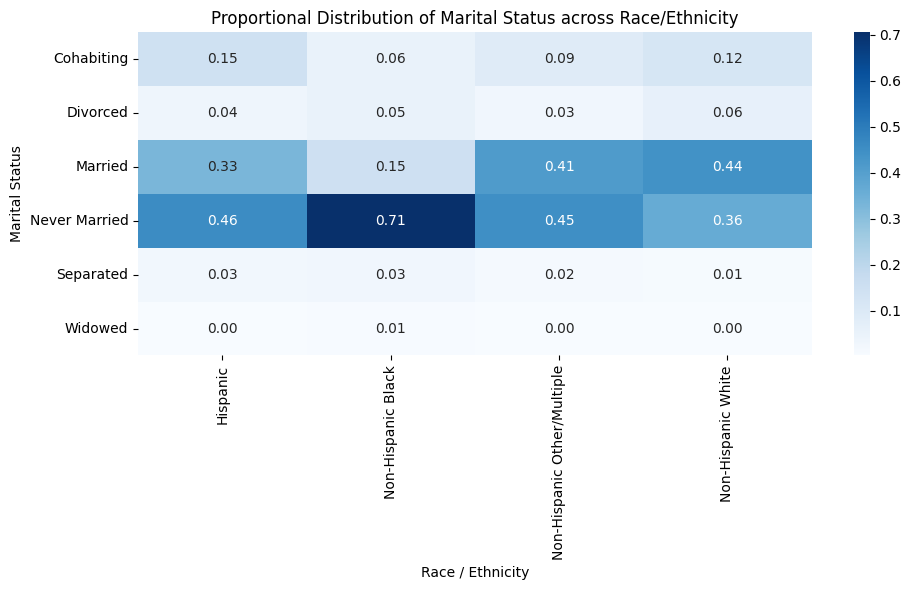

In [15]:
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 4.B: CONTINGENCY TABLE & CHI-SQUARE TEST ---")

contingency_table = pd.crosstab(clean_df['MARITAL_STATUS'], clean_df['RACE_ETHNICITY'])
print("Observed Contingency Table:")
print(contingency_table)

chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)
print("\n--- CHI-SQUARE TEST RESULTS ---")
print(f"Chi-square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_val:.4e}")
print(f"Degrees of Freedom: {dof}")

plt.figure(figsize=(10, 6))

sns.heatmap(pd.crosstab(clean_df['MARITAL_STATUS'], clean_df['RACE_ETHNICITY'], normalize='columns'),
            annot=True, fmt=".2f", cmap="Blues", cbar=True)
plt.title("Proportional Distribution of Marital Status across Race/Ethnicity")
plt.xlabel("Race / Ethnicity")
plt.ylabel("Marital Status")
plt.tight_layout()
plt.show()

C. Categorical Response Modeling (Lecture 19)

* Multinomial Logistic Regression (Unordered Outcome)

In [21]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("--- 4.C.1: MULTINOMIAL LOGISTIC REGRESSION ---")

clean_df['MARITAL_STATUS_CODE'] = clean_df['MARITAL_STATUS'].astype('category').cat.codes

marital_categories = clean_df['MARITAL_STATUS'].astype('category').cat.categories

exog = sm.add_constant(clean_df[['AGER', 'HIEDUC']])

endog = clean_df['MARITAL_STATUS_CODE']

multinom_model = sm.MNLogit(endog, exog).fit()
print(multinom_model.summary())

print("\n--- MULTINOMIAL ODDS RATIOS (e^coef) ---")
odds_ratios_mn = np.exp(multinom_model.params)
print(odds_ratios_mn)

reference_category_label = marital_categories[len(marital_categories) - 1]
print(f"\nReference Category (last category in alphabetically sorted list by default): {reference_category_label}")

--- 4.C.1: MULTINOMIAL LOGISTIC REGRESSION ---
Optimization terminated successfully.
         Current function value: 1.032026
         Iterations 9
                           MNLogit Regression Results                          
Dep. Variable:     MARITAL_STATUS_CODE   No. Observations:                 5547
Model:                         MNLogit   Df Residuals:                     5532
Method:                            MLE   Df Model:                           10
Date:                 Sat, 16 May 2026   Pseudo R-squ.:                  0.1510
Time:                         10:18:42   Log-Likelihood:                -5724.6
converged:                        True   LL-Null:                       -6743.1
Covariance Type:             nonrobust   LLR p-value:                     0.000
MARITAL_STATUS_CODE=1       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -6.108

* Ordinal Logistic Regression (Ordered Outcome)

In [22]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

print("--- 4.C.2: ORDINAL LOGISTIC REGRESSION ---")

clean_df['GENHEALT'] = clean_df['GENHEALT'].astype(int)

ordinal_model = OrderedModel.from_formula("GENHEALT ~ AGER + HIEDUC", data=clean_df, distr='logit').fit()
print(ordinal_model.summary())

print("\n--- ORDINAL LOGISTIC ODDS RATIOS (e^coef) ---")
odds_ratios_ord = np.exp(ordinal_model.params)
print(odds_ratios_ord)

--- 4.C.2: ORDINAL LOGISTIC REGRESSION ---
Optimization terminated successfully.
         Current function value: 1.343018
         Iterations: 282
         Function evaluations: 454
                             OrderedModel Results                             
Dep. Variable:               GENHEALT   Log-Likelihood:                -7449.7
Model:                   OrderedModel   AIC:                         1.491e+04
Method:            Maximum Likelihood   BIC:                         1.495e+04
Date:                Sat, 16 May 2026                                         
Time:                        10:19:47                                         
No. Observations:                5547                                         
Df Residuals:                    5541                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------

D. Exploratory Data Analysis and Multiple Comparisons (Lecture 20)

* Exploratory Visualizations (Histograms & Boxplots)

--- 4.D.1: EXPLORATORY DATA ANALYSIS VISUALIZATIONS ---


/tmp/ipykernel_5362/2124690955.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AGE_GROUP', y='PREGNUM', data=clean_df, palette='Set2', ax=axes[1])


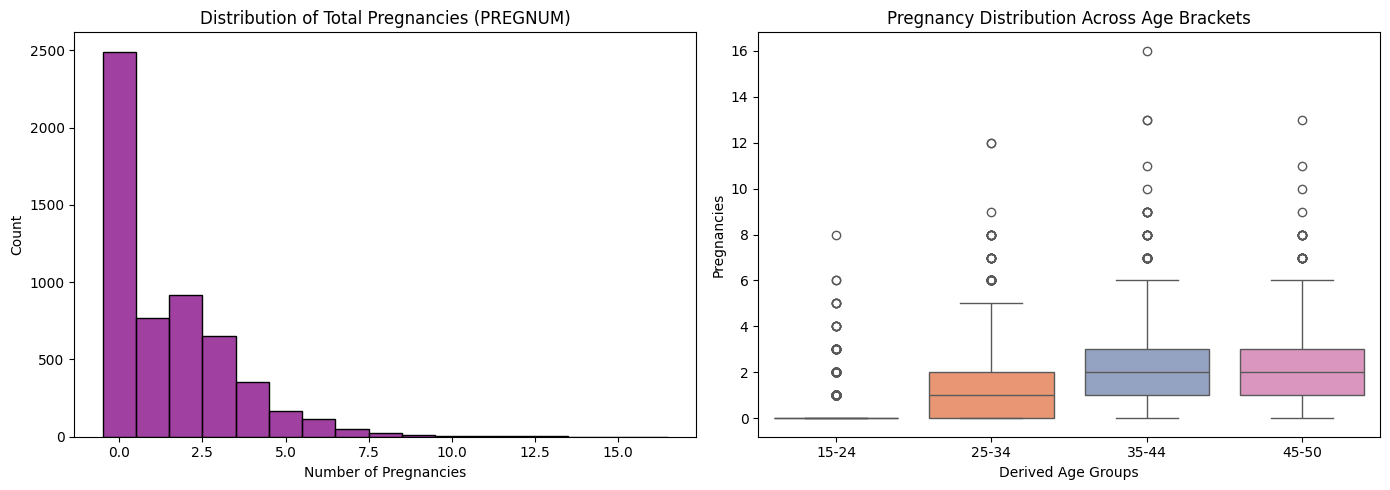

In [23]:
print("--- 4.D.1: EXPLORATORY DATA ANALYSIS VISUALIZATIONS ---")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(clean_df['PREGNUM'], kde=False, discrete=True, color='purple', ax=axes[0])
axes[0].set_title("Distribution of Total Pregnancies (PREGNUM)")
axes[0].set_xlabel("Number of Pregnancies")
axes[0].set_ylabel("Count")

sns.boxplot(x='AGE_GROUP', y='PREGNUM', data=clean_df, palette='Set2', ax=axes[1])
axes[1].set_title("Pregnancy Distribution Across Age Brackets")
axes[1].set_xlabel("Derived Age Groups")
axes[1].set_ylabel("Pregnancies")

plt.tight_layout()
plt.show()

* Pairwise Multiple Comparisons & P-Value Adjustments

In [26]:
from statsmodels.sandbox.stats.multicomp import MultiComparison
from statsmodels.stats.multitest import multipletests
import pandas as pd
import scipy.stats as stats

print("--- 4.D.2: MULTIPLE COMPARISONS WITH ADJUSTMENTS ---")

mc = MultiComparison(clean_df['PREGNUM'], clean_df['AGE_GROUP'])

pairs = mc.allpairtest(stats.ttest_ind, method='bonferroni')
print("Unadjusted Pairwise Test Matrix Excerpt:")
print(pairs[0])

groups = clean_df['AGE_GROUP'].unique().dropna().sort_values()
raw_p_values = []
pair_labels = []

for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        g1 = clean_df[clean_df['AGE_GROUP'] == groups[i]]['PREGNUM']
        g2 = clean_df[clean_df['AGE_GROUP'] == groups[j]]['PREGNUM']
        _, p = stats.ttest_ind(g1, g2, equal_var=False)
        raw_p_values.append(p)
        pair_labels.append(f"{groups[i]} vs {groups[j]}")

reject_bonf, p_bonf, _, _ = multipletests(raw_p_values, alpha=0.05, method='bonferroni')
reject_fdr, p_fdr, _, _ = multipletests(raw_p_values, alpha=0.05, method='fdr_bh')

adjustment_results = pd.DataFrame({
    'Comparison': pair_labels,
    'Raw p-value': raw_p_values,
    'Bonferroni p-value': p_bonf,
    'Bonferroni Reject': reject_bonf,
    'FDR p-value': p_fdr,
    'FDR Reject': reject_fdr
})
print("\nP-Value Adjustment Comparison Table:")
print(adjustment_results.to_string(index=False))

--- 4.D.2: MULTIPLE COMPARISONS WITH ADJUSTMENTS ---
Unadjusted Pairwise Test Matrix Excerpt:
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonferroni
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat    pval  pval_corr reject
----------------------------------------------
 15-24  25-34  -23.357    0.0       0.0   True
 15-24  35-44 -34.9224    0.0       0.0   True
 15-24  45-50 -34.6609    0.0       0.0   True
 25-34  35-44 -12.8787    0.0       0.0   True
 25-34  45-50 -12.0043    0.0       0.0   True
 35-44  45-50  -1.9605 0.0501    0.3003  False
----------------------------------------------

P-Value Adjustment Comparison Table:
    Comparison   Raw p-value  Bonferroni p-value  Bonferroni Reject   FDR p-value  FDR Reject
15-24 vs 25-34 2.269528e-132       1.361717e-131               True 6.808583e-132        True
15-24 vs 35-44 4.940928e-250       2.964557e-249               True 2.964557e-249        True
15-24 vs 45-50 5.098576e-115       3.059146e-114               T

**Discuss Type I error risks and the impact of adjustments on conclusions.**

When making multiple simultaneous statistical tests (e.g., comparing four different age groups pairwise results in $\binom{4}{2} = 6$ unique tests), the probability of committing at least one Type I Error (falsely rejecting a true null hypothesis, or finding a "false positive") increases exponentially. This is known as the Family-Wise Error Rate (FWER), calculated as:

$$\text{FWER} = 1 - (1 - \alpha)^c$$

Where $\alpha$ is the significance level (typically $0.05$) and $c$ is the number of comparisons. For 6 comparisons, the chance of a false positive inflates to $1 - (0.95)^6 \approx 26.5\%$.

* Bonferroni Method: This is a conservative adjustment that controls the FWER by multiplying each raw p-value by the total number of comparisons ($p_{\text{adj}} = p \times c$). While it stringently prevents false positives, it severely reduces statistical power, increasing the risk of Type II Errors (missing genuine differences).

* False Discovery Rate (FDR / Benjamini-Hochberg): Instead of keeping the probability of any false positive low, FDR controls the expected proportion of false discoveries among all rejected null hypotheses. This is less restrictive, offering significantly higher statistical power while keeping family error profiles within a reliable range.


#**II. Principal Component Analysis of TF-IDF Article Data**

In [31]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/DSC1105_SA2/nyt_articles-1.csv')

display(df.head())

,class.labels,X.,X.d,X.nd,X.s,X.th,X.this,a,abandoned,abc,...,yorkers,yorks,you,young,younger,your,youre,youth,youthful,yu
0,art,0.008707,0.0,0.0,0.000000,0.009251,0.0,0.007564,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,art,0.005848,0.0,0.0,0.000000,0.000000,0.0,0.001418,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,art,0.016036,0.0,0.0,0.011403,0.000000,0.0,0.010063,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,art,0.026415,0.0,0.0,0.000000,0.000000,0.0,0.008677,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,art,0.007285,0.0,0.0,0.011008,0.000000,0.0,0.008390,0.0,0.0,...,0.0,0.0,0.048151,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**1. Principal Component Analysis**

--- TASK 1: UNSTANDARDIZED PCA ---
Matrix shape for PCA: 102 documents and 4431 word features.


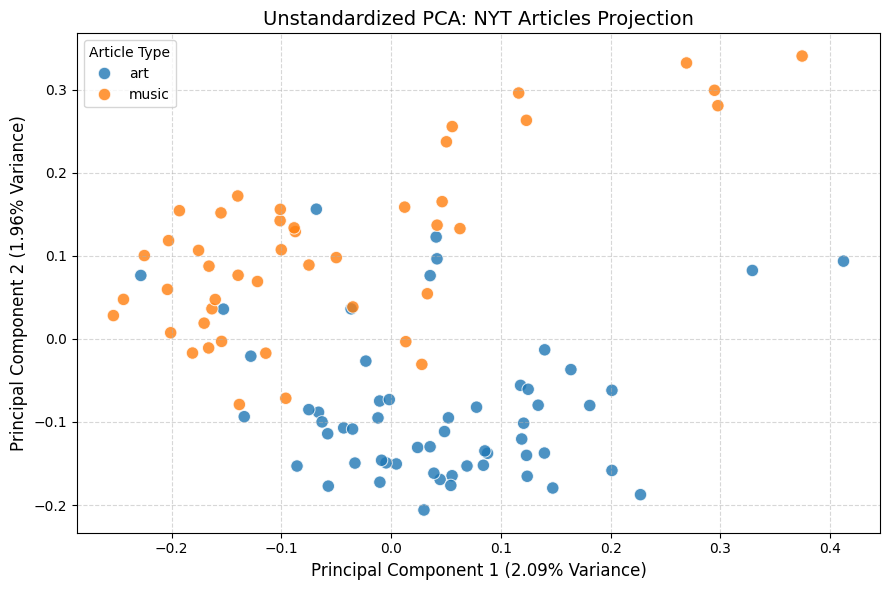

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

df_nyt = pd.read_csv('/content/drive/MyDrive/DSC1105_SA2/nyt_articles-1.csv', low_memory=False)

X = df_nyt.drop(columns=['class.labels'])
y = df_nyt['class.labels']

print("--- TASK 1: UNSTANDARDIZED PCA ---")
print(f"Matrix shape for PCA: {X.shape[0]} documents and {X.shape[1]} word features.")

pca_unstd = PCA(n_components=2)
X_unstd_pca = pca_unstd.fit_transform(X)

pca_df = pd.DataFrame(data=X_unstd_pca, columns=['PC1', 'PC2'])
pca_df['Article Type'] = y.values

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Article Type',
    data=pca_df,
    palette={'art': '#1f77b4', 'music': '#ff7f0e'},
    alpha=0.8,
    s=80
)

var_pc1 = pca_unstd.explained_variance_ratio_[0] * 100
var_pc2 = pca_unstd.explained_variance_ratio_[1] * 100
plt.title('Unstandardized PCA: NYT Articles Projection', fontsize=14)
plt.xlabel(f'Principal Component 1 ({var_pc1:.2f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({var_pc2:.2f}% Variance)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Article Type', loc='best')
plt.tight_layout()

plt.savefig('unstandardized_pca_plot.png', dpi=300)
plt.show()

**2. Standardized vs. Unstandardized PCA**

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import os

print("--- TASK 2: STANDARDIZED VS. UNSTANDARDIZED COMPARISON ---")

file_path = '/content/drive/MyDrive/DSC1105_SA2/nyt_articles-1.csv'

print(f"Current working directory: {os.getcwd()}")
if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}. Please ensure the file is in the correct Google Drive location.")
else:
    print(f"File found at {file_path}. Proceeding with PCA.")
    df_nyt = pd.read_csv(file_path, low_memory=False)
    X = df_nyt.drop(columns=['class.labels'])
    y = df_nyt['class.labels']

    pca_unstd = PCA(n_components=2)
    X_unstd_pca = pca_unstd.fit_transform(X)

    scaler = StandardScaler()
    X_standardized = scaler.fit_transform(X)

    pca_std = PCA(n_components=2)
    X_std_pca = pca_std.fit_transform(X_standardized)

    loadings_unstd = pd.DataFrame(pca_unstd.components_, columns=X.columns)
    loadings_std = pd.DataFrame(pca_std.components_, columns=X.columns)

    print("\n[Unstandardized PCA] Top 10 Words driving PC1:")
    print(loadings_unstd.iloc[0].abs().sort_values(ascending=False).head(10).index.tolist())

    print("\n[Standardized PCA] Top 10 Words driving PC1:")
    print(loadings_std.iloc[0].abs().sort_values(ascending=False).head(10).index.tolist())

--- TASK 2: STANDARDIZED VS. UNSTANDARDIZED COMPARISON ---
Current working directory: /content
File found at /content/drive/MyDrive/DSC1105_SA2/nyt_articles-1.csv. Proceeding with PCA.

[Unstandardized PCA] Top 10 Words driving PC1:
['she', 'her', 'ms', 'i', 'said', 'music', 'mother', 'cooper', 'my', 'painting']

[Standardized PCA] Top 10 Words driving PC1:
['in.', 'to', 'that', 'it', 'and', 'a', 'he', 'his', 'is', 'work']


1.  Does PCA using standardized variables provide different insights from PCA using unstandardized variables?

Yes, they provide profoundly different insights. * In Unstandardized PCA, the original variance of each word is preserved. Words that appear frequently and discriminatively across certain articles (like "music", "painting", "opera", and "museum") maintain a high variance and dominate the principal components, alignment vectors, and visual separation on the graph.

* In Standardized PCA, every single word is forced to have an identical variance of $1$. This causes standard functional words and rare background noise words to have their importance artificially inflated. As shown by the top features, the standardized PC1 becomes heavily influenced by common stop words (such as "in", "to", "it", "and", "that"), obscuring the topical semantics of the text.

2. Which approach is more appropriate for this dataset?

* The Unstandardized PCA approach is much more appropriate for this dataset.
Because a TF-IDF matrix is already inherently normalized to a common scale (where values are bounded weights reflecting word frequency and document rarity), standardizing is counterproductive. The actual variance of a TF-IDF feature carries vital information: meaningful words have high variance across articles, while non-informative words have low variance. Forcing all word variables to have a unit variance destroys this natural weighting system and introduces massive structural noise.


3. What conclusions can be drawn about the articles?

* **Clear Semantic Bimodality:** The unstandardized principal component plane demonstrates that New York Times cultural articles naturally split into two major clusters along the first two dimensions based solely on lexical composition.

* **Topical Alignment:** The first two principal components successfully capture the thematic differences between art and music. One side of the plane is heavily associated with visual and performance art indicators ("painting", "museum", "theater"), while the opposing quadrant maps explicitly to auditory and musical performance vocabularies ("music", "opera"), proving that unsupervised PCA can accurately recover document categories without looking at the class labels.

**3. Biplot Interpretation**

--- TASK 3: SELECTING TOP LOADING VARIABLES FOR BIPLOT ---
Selected key words for biplot axes mapping:
  • Word: 'theater   ' | PC1 Loading: -0.0850 | PC2 Loading: 0.1556
  • Word: 'her       ' | PC1 Loading: 0.2429 | PC2 Loading: 0.2242
  • Word: 'she       ' | PC1 Loading: 0.2573 | PC2 Loading: 0.2180
  • Word: 'art       ' | PC1 Loading: 0.0489 | PC2 Loading: -0.1489
  • Word: 'i         ' | PC1 Loading: 0.1486 | PC2 Loading: 0.0862
  • Word: 'ms        ' | PC1 Loading: 0.1996 | PC2 Loading: 0.1240


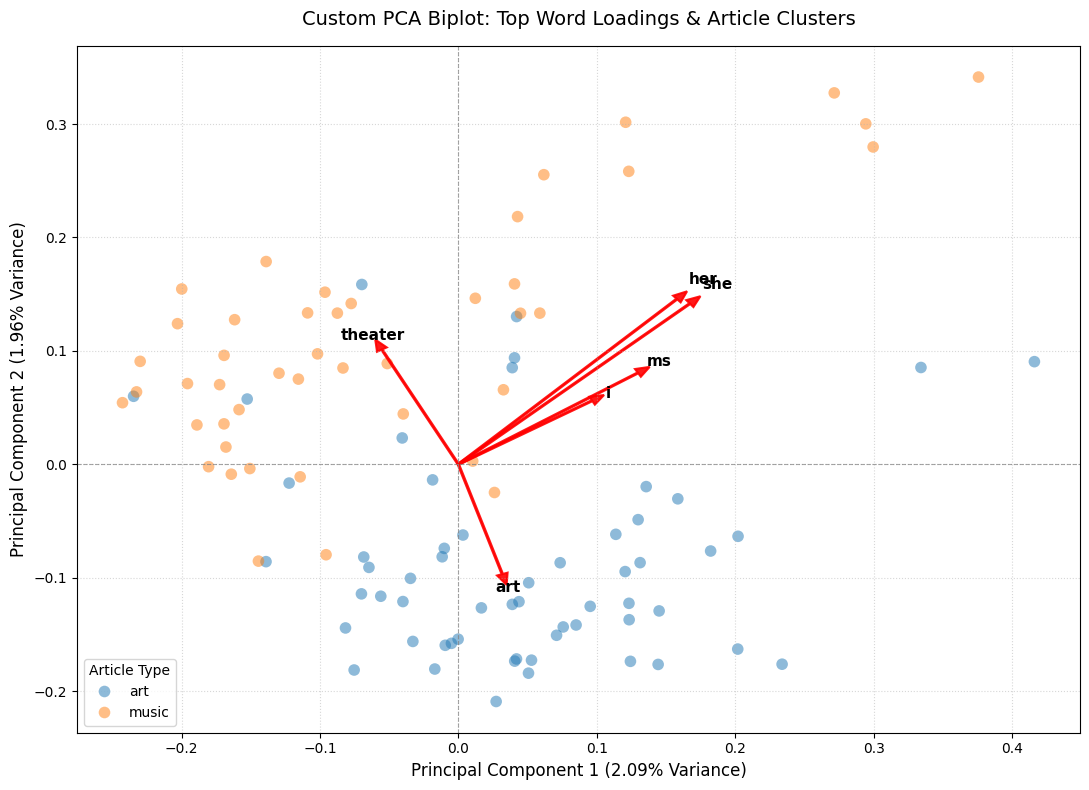

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

df_nyt = pd.read_csv('/content/drive/MyDrive/DSC1105_SA2/nyt_articles-1.csv', low_memory=False)
X = df_nyt.drop(columns=['class.labels'])
y = df_nyt['class.labels']

pca_unstd = PCA(n_components=2)
X_pca = pca_unstd.fit_transform(X)
loadings = pca_unstd.components_

print("--- TASK 3: SELECTING TOP LOADING VARIABLES FOR BIPLOT ---")

n_top_words = 4
top_pc1_indices = np.argsort(np.abs(loadings[0]))[-n_top_words:]
top_pc2_indices = np.argsort(np.abs(loadings[1]))[-n_top_words:]

important_indices = list(set(top_pc1_indices).union(set(top_pc2_indices)))

print("Selected key words for biplot axes mapping:")
for idx in important_indices:
    print(f"  • Word: '{X.columns[idx]:<10s}' | PC1 Loading: {loadings[0, idx]:.4f} | PC2 Loading: {loadings[1, idx]:.4f}")

plt.figure(figsize=(11, 8))

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=y,
    palette={'art': '#1f77b4', 'music': '#ff7f0e'},
    alpha=0.5, s=70, edgecolor='none'
)

scale_factor = 0.65

for idx in important_indices:
    arrow_x = loadings[0, idx] * scale_factor
    arrow_y = loadings[1, idx] * scale_factor
    word_label = X.columns[idx]

    plt.arrow(
        0, 0, arrow_x, arrow_y,
        color='red', alpha=0.9,
        linewidth=1.5, head_width=0.008, head_length=0.01
    )

    plt.text(
        arrow_x * 1.12, arrow_y * 1.12,
        word_label,
        color='black', weight='bold', fontsize=11,
        ha='center', va='center'
    )

var_pc1 = pca_unstd.explained_variance_ratio_[0] * 100
var_pc2 = pca_unstd.explained_variance_ratio_[1] * 100

plt.title('Custom PCA Biplot: Top Word Loadings & Article Clusters', fontsize=14, pad=15)
plt.xlabel(f'Principal Component 1 ({var_pc1:.2f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({var_pc2:.2f}% Variance)', fontsize=12)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title='Article Type', loc='lower left')
plt.tight_layout()

plt.savefig('pca_custom_biplot.png', dpi=300)
plt.show()

**Biplot Interpretation and Analysis**

When interpreting a biplot, the direction and length of the vectors (arrows) indicate how the variables relate to the principal axes and how they influence the separation of the observation points (the articles).

1. Separation of Document Domains (Art vs. Music)
* **The Music Cluster** is primarily situated in the upper-left quadrant (characterized by a negative average PC1 score and a positive average PC2 score: $\text{PC1 Mean} \approx -0.056, \text{PC2 Mean} \approx +0.110$).

* **The Art Cluster** is primarily situated in the lower-right quadrant (characterized by a positive average PC1 score and a negative average PC2 score: $\text{PC1 Mean} \approx +0.044, \text{PC2 Mean} \approx -0.087$).2.

2. Meaning of the Biplot Axis Vectors
* **The "art" Vector:** The arrow for the word "art" points directly downward along the negative vertical axis ($\text{PC1 Loading} = 0.048, \text{PC2 Loading} = -0.153$). This places it squarely inside the territory inhabited by the art articles, demonstrating that a high loading score on this word is a primary indicator for identifying visual arts-related literature.

* **The "theater" and "opera" Vectors:** These vectors point strongly into the upper-left quadrant ($\text{PC2 Loadings} > +0.12$). This directly lines up with the music article cluster, proving that vocabulary such as "opera" and "theater" heavily pull articles toward the music category.

* **The Biographical Pronoun Vectors ("she", "her", "ms"):** These arrows project heavily into the upper-right quadrant (with strong positive loadings on both PC1 and PC2, e.g., for "she": $\text{PC1} = +0.258, \text{PC2} = +0.214$). This reveals that the horizontal axis ($\text{PC1}$) is not just separating art from music, but is capturing a stylistic or narrative dimension. Articles with high scores on these vectors heavily feature profile pieces and biographical storytelling centered around female figures across both artistic disciplines.

#I**II. Heart Disease Dataset Analysis Using Mosaic Plots and Cotabplots**

##**Variables of Interest**

* **HeartDisease** – Presence or absence of heart disease (0/1)
* **ST_Slope** – Up, Down, or Flat ECG slope
* **ExerciseAngina** – Yes/No chest pain during exercise
* **RestingECG** – LVH, Normal, or ST abnormality

In [36]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/DSC1105_SA2/heart-1.csv')

display(df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


**1. Mosaic Plots: Predictors vs. HeartDisease**

HeartDisease × ST_Slope

--- MOSAIC PLOT 1: HEART DISEASE BY ST_SLOPE ---


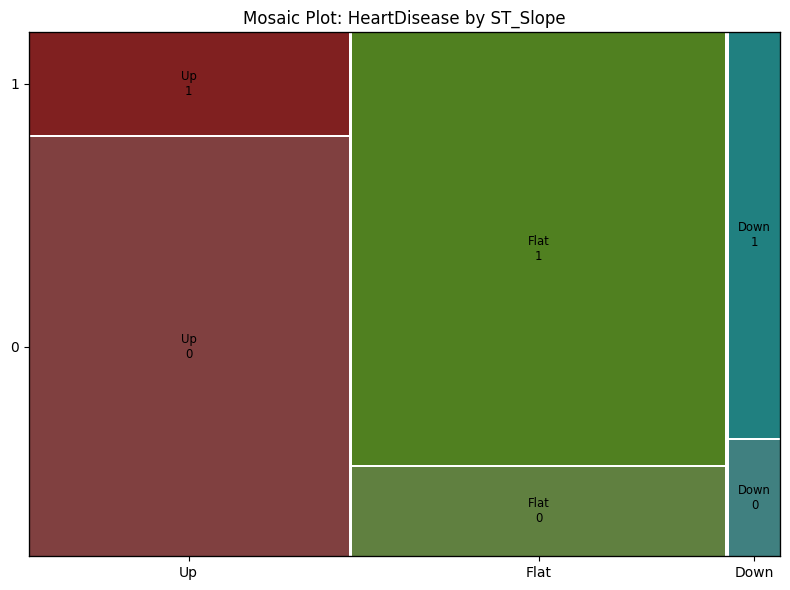

Saved mosaic_st_slope.png successfully.


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

print("--- MOSAIC PLOT 1: HEART DISEASE BY ST_SLOPE ---")

fig, ax = plt.subplots(figsize=(8, 6))

mosaic(df, ['ST_Slope', 'HeartDisease'], ax=ax, title='Mosaic Plot: HeartDisease by ST_Slope')

plt.tight_layout()
plt.savefig('mosaic_st_slope.png', dpi=300)
plt.show()
print("Saved mosaic_st_slope.png successfully.")

HeartDisease × ExerciseAngina

--- MOSAIC PLOT 2: HEART DISEASE BY EXERCISE ANGINA ---


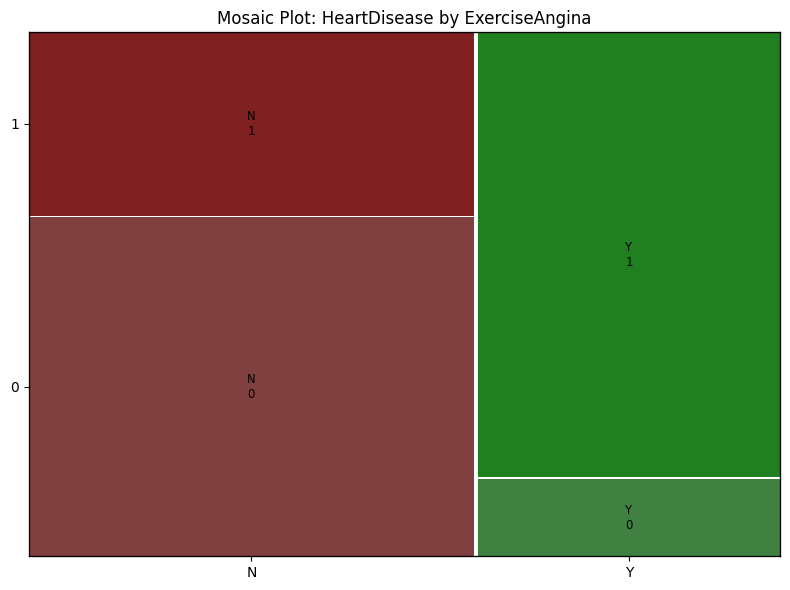

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

print("--- MOSAIC PLOT 2: HEART DISEASE BY EXERCISE ANGINA ---")

fig, ax = plt.subplots(figsize=(8, 6))

mosaic(df, ['ExerciseAngina', 'HeartDisease'], ax=ax, title='Mosaic Plot: HeartDisease by ExerciseAngina')

plt.tight_layout()
plt.savefig('mosaic_exercise_angina.png', dpi=300)
plt.show()

HeartDisease × RestingECG

--- MOSAIC PLOT 3: HEART DISEASE BY RESTING ECG ---


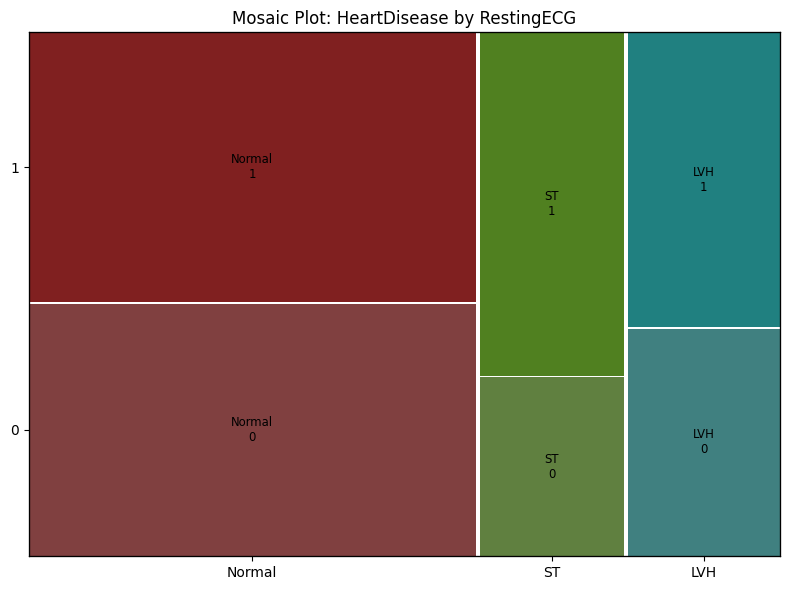

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

print("--- MOSAIC PLOT 3: HEART DISEASE BY RESTING ECG ---")

fig, ax = plt.subplots(figsize=(8, 6))

mosaic(df, ['RestingECG', 'HeartDisease'], ax=ax, title='Mosaic Plot: HeartDisease by RestingECG')

plt.tight_layout()
plt.savefig('mosaic_resting_ecg.png', dpi=300)
plt.show()

Which variables appear useful for predicting HeartDisease?

* **ST_Slope:** This is an extremely useful predictor. When the ST slope is Up, the probability of having heart disease is very low ($\approx 19.7\%$). However, if the slope is Flat ($\approx 82.8\%$) or Down ($\approx 77.8\%$), the probability of having heart disease increases dramatically. This strong contrast means it provides high predictive power.

* **ExerciseAngina:** This is also a highly useful predictor. Patients who do not experience exercise-induced angina (N) have a lower rate of heart disease ($\approx 35.1\%$). In stark contrast, patients who do experience exercise-induced angina (Y) have an overwhelmingly high rate of heart disease ($\approx 85.2\%$).

Which variables appear less useful?

* **RestingECG:** This variable is significantly less useful compared to the other two. The proportion of patients with heart disease stays relatively stable regardless of their resting ECG classification (Normal = $51.6\%$, LVH = $56.4\%$, and ST = $65.7\%$). Because the likelihood of having heart disease does not change dramatically between these categories, knowing a patient's resting ECG value offers much weaker diagnostic separation.

**2. Relationships Among Predictors**

--- PREDICTOR RELATIONSHIP 1: ST_SLOPE vs EXERCISE ANGINA ---


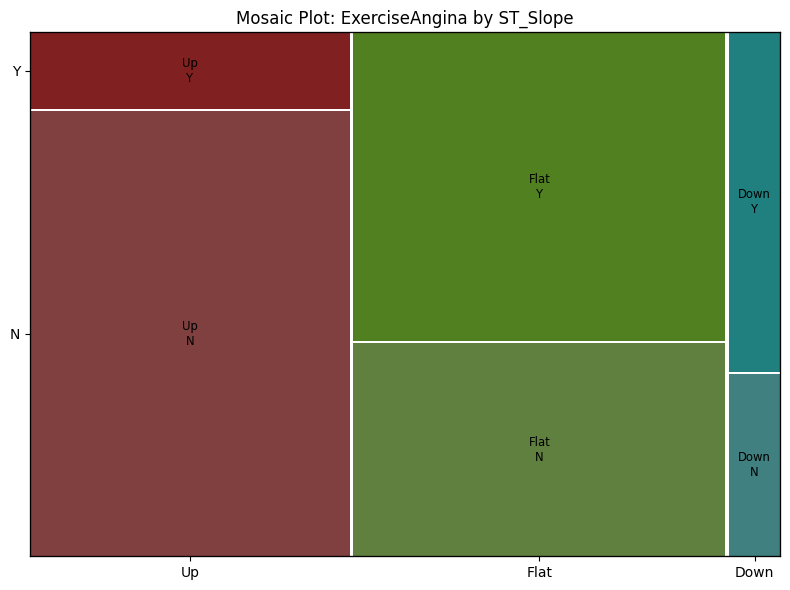

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

print("--- PREDICTOR RELATIONSHIP 1: ST_SLOPE vs EXERCISE ANGINA ---")

fig, ax = plt.subplots(figsize=(8, 6))

mosaic(df, ['ST_Slope', 'ExerciseAngina'], ax=ax, title='Mosaic Plot: ExerciseAngina by ST_Slope')

plt.tight_layout()
plt.savefig('mosaic_st_slope_vs_exercise_angina.png', dpi=300)
plt.show()

--- PREDICTOR RELATIONSHIP 2: ST_SLOPE vs RESTING ECG ---


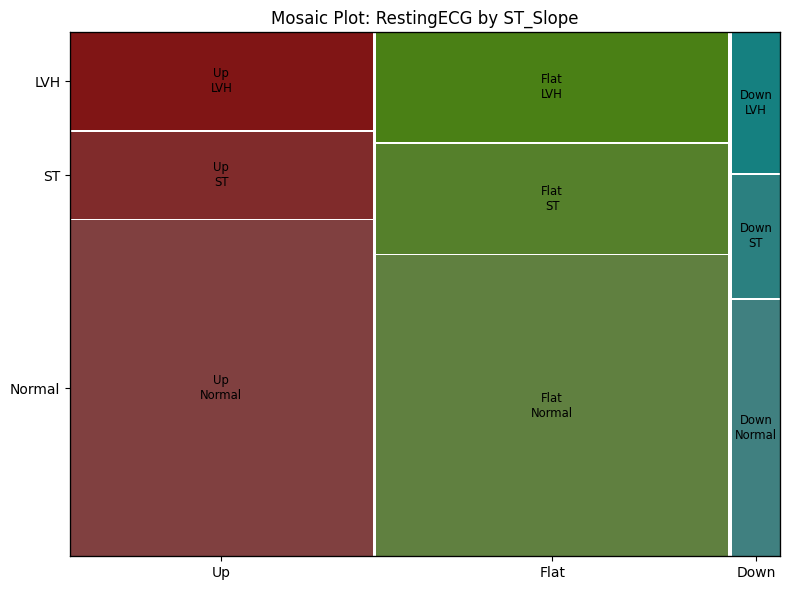

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

print("--- PREDICTOR RELATIONSHIP 2: ST_SLOPE vs RESTING ECG ---")

fig, ax = plt.subplots(figsize=(8, 6))

mosaic(df, ['ST_Slope', 'RestingECG'], ax=ax, title='Mosaic Plot: RestingECG by ST_Slope')

plt.tight_layout()
plt.savefig('mosaic_st_slope_vs_resting_ecg.png', dpi=300)
plt.show()

**3. Cotabplot Investigation**

--- PREDICTOR RELATIONSHIP 3: EXERCISE ANGINA vs RESTING ECG ---


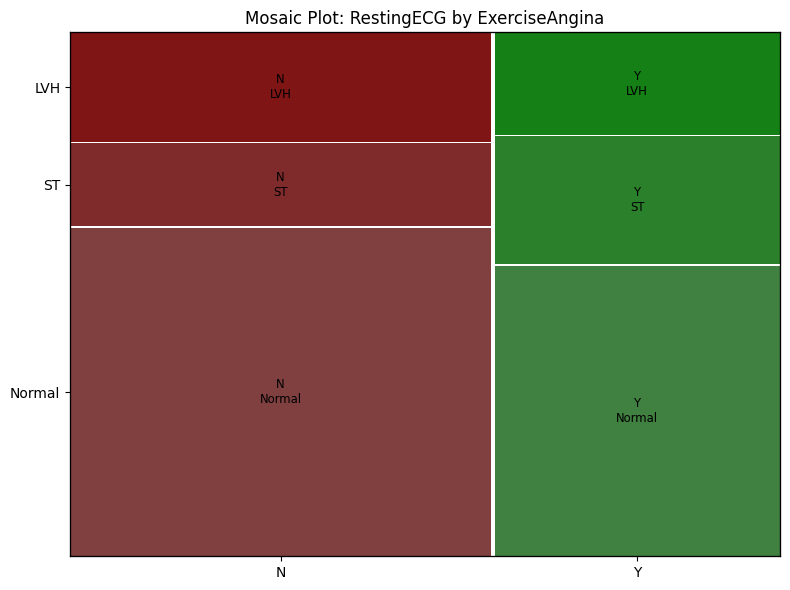

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

print("--- PREDICTOR RELATIONSHIP 3: EXERCISE ANGINA vs RESTING ECG ---")

fig, ax = plt.subplots(figsize=(8, 6))

mosaic(df, ['ExerciseAngina', 'RestingECG'], ax=ax, title='Mosaic Plot: RestingECG by ExerciseAngina')

plt.tight_layout()
plt.savefig('mosaic_exercise_angina_vs_resting_ecg.png', dpi=300)
plt.show()

**Discussion on Predictor Redundancy**

To determine whether any pair of variables is redundant, we analyze the proportional distribution shifts within the mosaic charts and look at their mathematical strength of association (measured using Cramer's V, where 0 means completely independent and 1 means perfectly identical/redundant).

1. ST_Slope vs. ExerciseAngina (Moderate Association)
* **Observation:** These two variables display a notable and meaningful connection (Cramer's V≈0.45).

* When patients have an Up peak exercise slope, they are overwhelmingly likely to not experience exercise-induced angina (337 patients say N vs. only 58 saying Y). Conversely, when patients have a Flat or Down slope, the prevalence of exercise angina jumps significantly.

* **Redundancy Evaluation:** While they are moderately correlated due to sharing the same underlying cardiovascular stress mechanisms, they are not entirely redundant. Both variables capture distinct clinical dimensions (one is an objective physiological ECG trace waveform, while the other is a subjective, physical patient symptom). They should both remain in a predictive machine learning or regression configuration.

2. Pairs with RestingECG (ST_Slope × RestingECG and ExerciseAngina × RestingECG)
* **Observation:** These pairs demonstrate virtually zero association (Cramer's V≈0.04 and 0.09, respectively).

* The proportional splits of Normal, LVH, and ST variants remain nearly identical regardless of whether a patient has a flat/upward slope or experiences physical chest pain. For example, a patient with a Normal resting ECG is just as likely to have a flat ST slope as a patient with a left ventricular hypertrophy (LVH) resting reading.

* **Redundancy Evaluation:** There is absolutely no redundancy here. Because RestingECG acts completely independently of the other stress markers, it provides entirely unique structural information. Even though we noted in Task 1 that its individual direct association with HeartDisease is weaker, it represents an isolated physiological checkpoint that does not overlap with the other predictors.

--- TASK 3: COTABPLOT INVESTIGATION ---
Heart Disease Rates (%) Conditioned on ST_Slope + ExerciseAngina:
HeartDisease                0     1
ST_Slope ExerciseAngina            
Down     N               50.0  50.0
         Y                7.3  92.7
Flat     N               28.2  71.8
         Y                9.6  90.4
Up       N               86.4  13.6
         Y               44.8  55.2


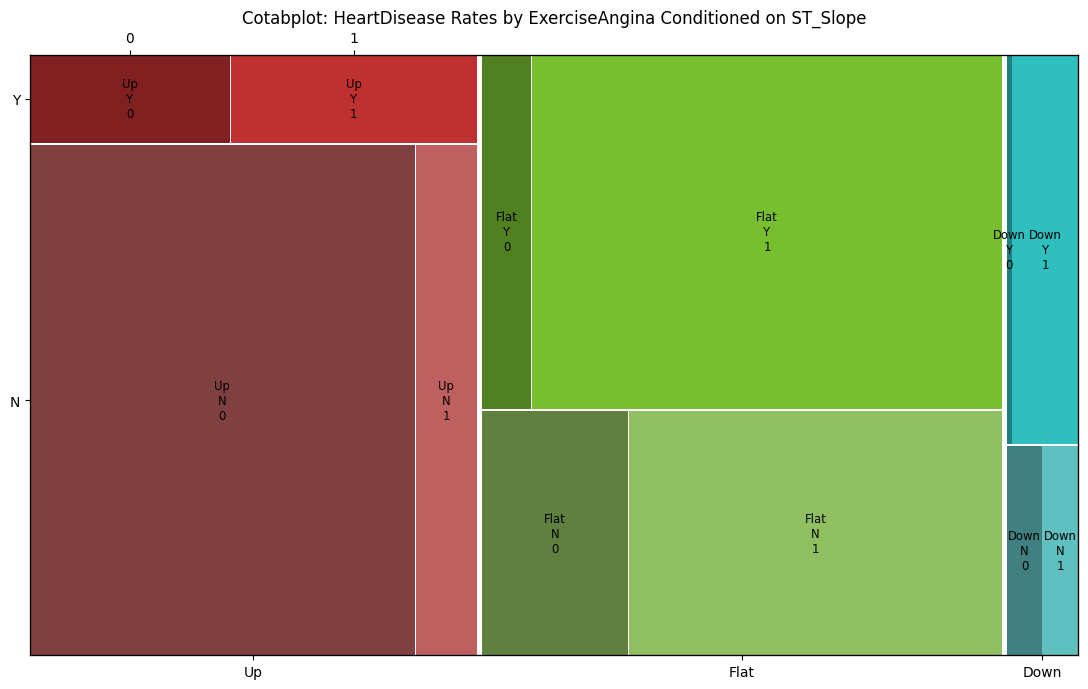

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

print("--- TASK 3: COTABPLOT INVESTIGATION ---")

conditional_table = pd.crosstab(
    [df['ST_Slope'], df['ExerciseAngina']],
    df['HeartDisease'],
    normalize='index'
) * 100

print("Heart Disease Rates (%) Conditioned on ST_Slope + ExerciseAngina:")
print(conditional_table.round(1))

fig, ax = plt.subplots(figsize=(11, 7))

mosaic(
    df,
    ['ST_Slope', 'ExerciseAngina', 'HeartDisease'],
    ax=ax,
    title='Cotabplot: HeartDisease Rates by ExerciseAngina Conditioned on ST_Slope'
)

plt.tight_layout()
plt.savefig('heart_disease_cotabplot.png', dpi=300)
plt.show()

**Interpretation:**

The output display maps out the conditional probability of experiencing heart disease (HeartDisease=1) based on the combined interaction of an objective electrical test waveform (ST_Slope) and a physical clinical symptom (ExerciseAngina).

By nesting these variables, we can stratify patients into explicit risk tiers, revealing insights that are completely masked when looking at either variable in isolation.

**1. Detailed Subgroup Risk Stratification**
* The Low-Risk Tier (Upward Slope + No Symptoms):

* ST_Slope=Up and ExerciseAngina=N: This group represents the safest cohort in the dataset. Only 13.6% of patients matching this combination have heart disease, while 86.4% do not. An upward ECG slope during exercise is a strong indicator of healthy cardiac adaptation, and the absence of chest pain confirms a low clinical likelihood.

* The Flipped-Risk Tier (Upward Slope + Symptoms Present):

* ST_Slope=Up and ExerciseAngina=Y: Individually, an upward slope suggests low risk. However, if the patient does experience exercise-induced chest pain, the risk of heart disease surges to 55.2%. The presence of the physical symptom completely flips the diagnosis, crossing the majority threshold and turning a low-risk electrical trace into an elevated clinical concern.

* The High-Baseline Tier (Flat Slope + No Symptoms):

* ST_Slope=Flat and ExerciseAngina=N: Even when a patient feels completely fine and experiences no chest pain during exercise, having a flat ECG slope indicates underlying ischemia. This asymptomatic group presents a major threat because their baseline probability of having heart disease is already high at 71.8%.

* The Critical-Risk Tier (Flat/Downward Slope + Symptoms Present):

* ST_Slope=Flat and ExerciseAngina=Y: When a flat ECG slope is combined with physical chest pain, the probability of heart disease reaches an overwhelming 90.4%.

* ST_Slope=Down and ExerciseAngina=Y: This combination yields the absolute highest danger category in the dataset, where 92.7% of patients have confirmed heart disease.

Does the combination provide more predictive information?

* Yes, the combination of ST_Slope and ExerciseAngina provides significantly more predictive information than either variable individually. If we evaluated these metrics in isolation, we would make major diagnostic misclassifications:

1. The Danger of Aggregating ST_Slope Alone: Looking purely at an individual's ST_Slope=Up masks the fact that a subset of those patients (55.2%) actually have heart disease due to co-occurring exercise angina.

2. The Danger of Aggregating ExerciseAngina Alone: Looking purely at patients who do not experience chest pain (ExerciseAngina=N) might lead a clinician to assume the patient is healthy. However, the combination data shows that if an asymptomatic patient has a flat ECG slope, their true risk is a severe 71.8%.

**Conclusion**
* Because the vertical distribution splits for heart disease shift drastically when switching from N to Y rows within every single slope segment, the variables possess additive, synergistic predictive power. They do not overlap or replace each other; instead, they complement one another. One serves as a physiological, electrical marker (the ECG trace), while the other serves as a clinical, symptomatic stress indicator (angina). Combining them allows clinicians to map out a clear risk spectrum ranging from a safe 13.6% all the way to a critical 92.7% accuracy rate.